# Baseline Model

---

## Table of Contents
1. [Imports & Setup](#1-imports--setup)
2. [Data Loading & Exploration](#2-data-loading--exploration)
3. [Preprocessing](#3-preprocessing)
4. [Train / Test Split](#4-train--test-split)
5. [Baseline Model — TF-IDF + Logistic Regression](#5-baseline-model)
6. [Evaluation](#6-evaluation)
7. [Conclusion & Next Steps](#7-conclusion--next-steps)

---
## 1. Imports & Setup

All imports are collected here at the top to make dependencies immediately visible. We also set a global random seed to ensure our results are reproducible.

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

LABEL_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print('All imports successful.')

All imports successful.


---
## 2. Data Loading & Exploration

Class imbalance is the biggest challenge in this dataset and will directly influence our modeling decisions.

In [5]:
df = pd.read_csv("../data/train/train.csv")

print(f'Dataset shape: {df.shape}')
print(f'\nColumn types:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')

Dataset shape: (159571, 8)

Column types:
id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

Missing values:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


In [17]:
df.sample(5)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
37943,654ae57e19d63ea3,"""\r\n No rule against it except, in this case,...",0,0,0,0,0,0
23167,3d3db51769df88bc,"""""""In fact BJJ despised wrestling up until the...",0,0,0,0,0,0
118351,7861d8374e9884cc,"sorry my bad, i really didnt see it, thought i...",0,0,0,0,0,0
118041,7680dfe1f0710d96,"""\r\n\r\n Language categorization \r\nI unders...",0,0,0,0,0,0
126138,a28c5bc63ba1d00f,"""\r\nmaybe you could try and get your message ...",1,0,1,0,0,0


### Label Distribution

Visualizing how many examples exist per label. There is a heavy imbalance, most comments are clean, and some toxic categories (like `threat`) will be very rare.

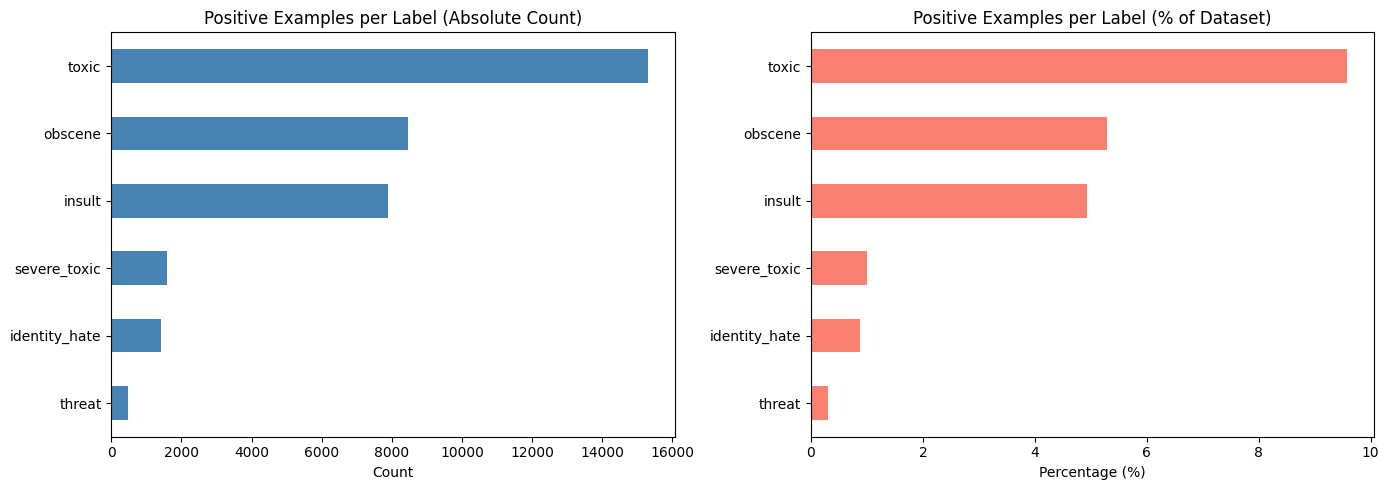


Label counts:
threat             478
identity_hate     1405
severe_toxic      1595
insult            7877
obscene           8449
toxic            15294


In [18]:
label_counts = df[LABEL_COLS].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
label_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Positive Examples per Label (Absolute Count)')
axes[0].set_xlabel('Count')

# As a percentage of total dataset
(label_counts / len(df) * 100).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Positive Examples per Label (% of Dataset)')
axes[1].set_xlabel('Percentage (%)')

plt.tight_layout()
plt.show()

print('\nLabel counts:')
print(label_counts.to_string())

### Multi-label Co-occurrence

Since this is multi-label, comments can have multiple labels at once. Thus checking how often labels appear together is important.

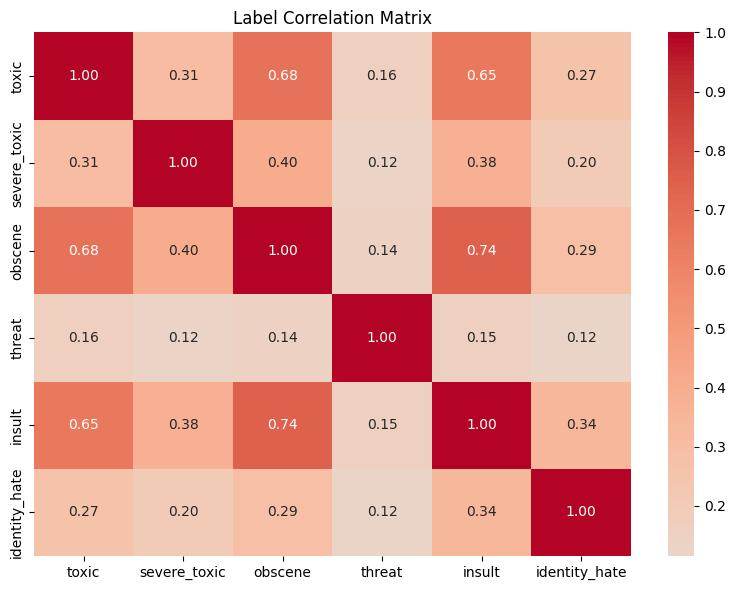

In [19]:
# Correlation between labels
plt.figure(figsize=(8, 6))
corr = df[LABEL_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Label Correlation Matrix')
plt.tight_layout()
plt.show()

### Comment Length Distribution

This helps us set TFIDF parameters and spot any outliers.

Comment length stats (words):
count    159571.000000
mean         67.273527
std          99.230702
min           1.000000
25%          17.000000
50%          36.000000
75%          75.000000
max        1411.000000
Name: comment_length, dtype: float64


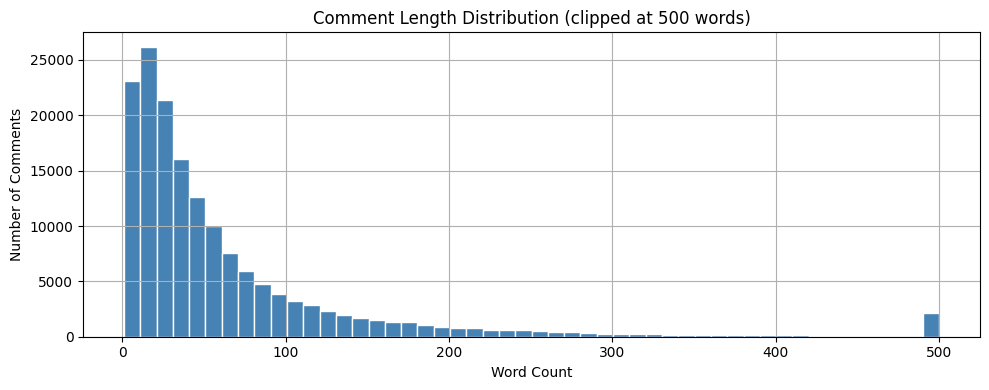

In [20]:
df['comment_length'] = df['comment_text'].str.split().str.len()

print(f'Comment length stats (words):')
print(df['comment_length'].describe())

plt.figure(figsize=(10, 4))
df['comment_length'].clip(upper=500).hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Comment Length Distribution (clipped at 500 words)')
plt.xlabel('Word Count')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

---
## 3. Preprocessing

- **Lowercase**
- **Remove line breaks**
- **Remove punctuation and special characters** we're keeping numbers as they can sometimes be relevant (e.g., slurs encoded as numbers)
- **Collapse whitespace**

We intentionally avoid stemming/lemmatization for this baseline.

In [22]:
def clean_text(text):
    """Clean a raw comment string for use with TF-IDF."""
    text = text.lower()                           
    text = re.sub(r'\r\n', ' ', text)            
    text = re.sub(r'[^a-z0-9\s]', ' ', text)     
    text = re.sub(r'\s+', ' ', text).strip()     
    return text

df['clean_text'] = df['comment_text'].apply(clean_text)

# Sanity check — compare raw vs cleaned 
print('=== BEFORE ===')
print(df['comment_text'].iloc[0][:300])
print('\n=== AFTER ===')
print(df['clean_text'].iloc[0][:300])

=== BEFORE ===
Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27

=== AFTER ===
explanation why the edits made under my username hardcore metallica fan were reverted they weren t vandalisms just closure on some gas after i voted at new york dolls fac and please don t remove the template from the talk page since i m retired now 89 205 38 27


---
## 4. Train / Test Split

20/80 split, no stratification, at this scale of dataset, this split should be representative

In [23]:
X = df['clean_text']
y = df[LABEL_COLS]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED
)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')

Training samples : 127,656
Test samples     : 31,915


---
## 5. Baseline Model

### TF-IDF + Logistic Regression

This is the standard starting point for text classification. It's fast to train , interpretable (we can inspect which words drive each prediction), and often surprisingly competitive. We use it to:
1. Establish a performance floor to beat
2. Verify our preprocessing and evaluation setup is working
3. Get fast feedback before committing to heavier models

### Key parameters:
- **`ngram_range=(1,2)`** — captures single words AND two-word phrases ("go die" is more toxic than "go" or "die" alone)
- **`max_features=50000`** — keeps the 50k most informative word/bigram combinations
- **`sublinear_tf=True`** — applies log scaling to term frequency, so rare but important words aren't drowned out by common ones
- **`class_weight='balanced'`** — compensates for class imbalance by giving higher loss to minority class mistakes
- **`MultiOutputClassifier`** — trains one independent logistic regression per label (6 total)

In [24]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True
    )),
    ('clf', MultiOutputClassifier(
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED)
    ))
])

print('Training...')
pipeline.fit(X_train, y_train)
print('Done.')

Training...
Done.


---
## 6. Evaluation

We evaluate using two complementary metrics:

- **ROC-AUC** — measures how well the model *ranks* toxic comments above clean ones. This is our primary metric because it's threshold-independent and handles class imbalance well. A score of 0.5 is random, 1.0 is perfect.
- **Classification Report** — shows precision, recall, and F1 at the default 0.5 threshold. Useful for understanding the precision/recall tradeoff.

For a content moderation use case, **recall matters more than precision**, missing toxic content is worse than occasionally flagging a clean comment.

In [25]:
# Get predictions and probabilities
y_pred = pipeline.predict(X_test)

X_test_tfidf = pipeline.named_steps['tfidf'].transform(X_test)
y_prob = np.array([
    est.predict_proba(X_test_tfidf)[:, 1]
    for est in pipeline.named_steps['clf'].estimators_
]).T

# ROC-AUC per label
print('=== ROC-AUC Scores ===')
auc_scores = {}
for i, col in enumerate(LABEL_COLS):
    auc = roc_auc_score(y_test[col], y_prob[:, i])
    auc_scores[col] = auc
    print(f'  {col:<20}: {auc:.4f}')

print(f'\n  {"Mean AUC":<20}: {np.mean(list(auc_scores.values())):.4f}')

=== ROC-AUC Scores ===
  toxic               : 0.9733
  severe_toxic        : 0.9833
  obscene             : 0.9849
  threat              : 0.9895
  insult              : 0.9797
  identity_hate       : 0.9687

  Mean AUC            : 0.9799


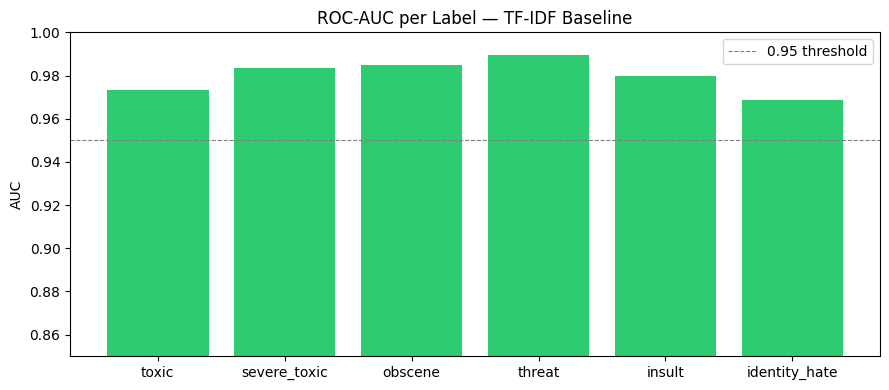

In [26]:
# AUC bar chart
plt.figure(figsize=(9, 4))
colors = ['#2ecc71' if v >= 0.95 else '#e67e22' if v >= 0.90 else '#e74c3c'
          for v in auc_scores.values()]
plt.bar(auc_scores.keys(), auc_scores.values(), color=colors)
plt.ylim(0.85, 1.0)
plt.axhline(y=0.95, color='gray', linestyle='--', linewidth=0.8, label='0.95 threshold')
plt.title('ROC-AUC per Label — TF-IDF Baseline')
plt.ylabel('AUC')
plt.legend()
plt.tight_layout()
plt.show()

### Inspecting the Model, Top Words per Label

One advantage of logistic regression is interpretability. We can look at which words carry the highest positive weight (most toxic signal) for each label.

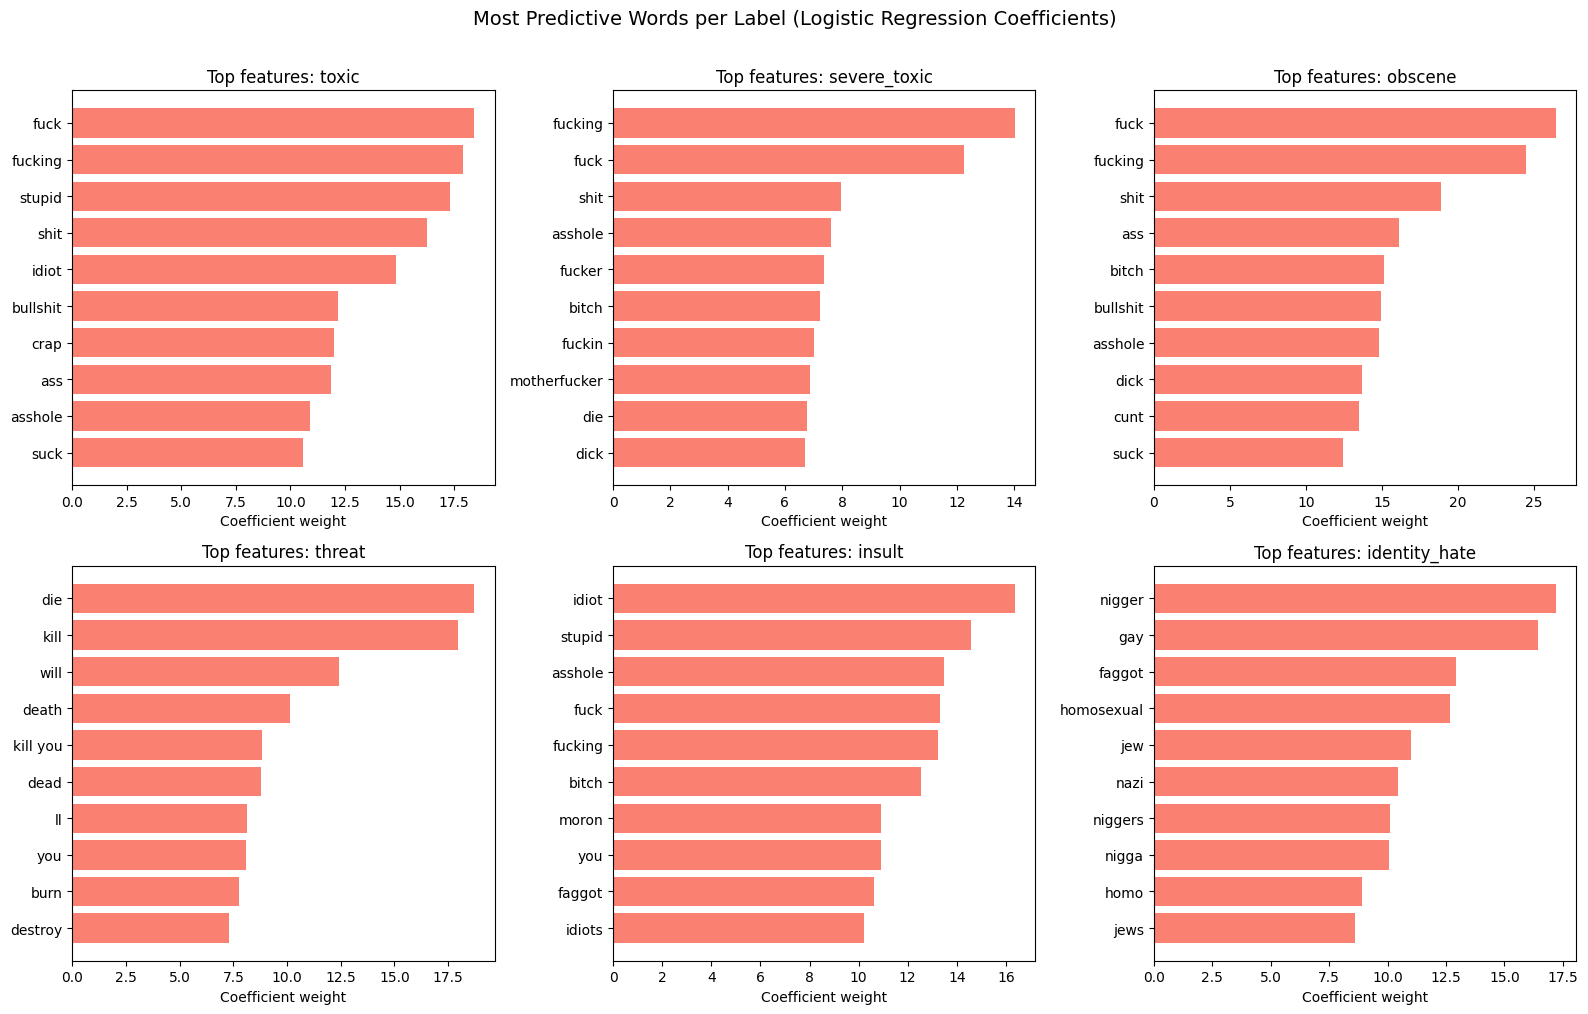

In [27]:
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
TOP_N = 10

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, estimator) in enumerate(zip(LABEL_COLS, pipeline.named_steps['clf'].estimators_)):
    coef = estimator.coef_[0]
    top_indices = np.argsort(coef)[-TOP_N:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    top_weights = coef[top_indices]

    axes[i].barh(top_words[::-1], top_weights[::-1], color='salmon')
    axes[i].set_title(f'Top features: {col}')
    axes[i].set_xlabel('Coefficient weight')

plt.suptitle('Most Predictive Words per Label (Logistic Regression Coefficients)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Conclusion & Next Steps

### Results Summary

- TF-IDF + Logistic Regression baseline achieves strong performance (AUC > 0.96 on average).
- Indicates clear lexical signals in toxic comments that bag-of-words models can capture.
- High recall across labels, the model detects most toxic content.
- Low precision on rare labels (threat, identity_hate).
- Many false positives, especially for underrepresented categories.
- Contributing factors:
    Use of class_weight='balanced'
    Limited training examples for rare labels

### Limitations of This Approach

- TF-IDF is a bag-of-words model (no understanding of word order).
- Cannot capture context or semantic meaning.
- Struggles with:
    Sarcasm
    Coded language
    Context-dependent toxicity
- Example: “go back to your country”, individually benign words, but toxic in context.

### Next Steps

1. **Tune the classification threshold** instead of using the default 0.5, find a threshold per label that optimizes the precision/recall tradeoff for our use case
2. **Fine-tune DistilBERT** — a pre-trained transformer that understands context and semantics; should significantly improve rare label performance
3. **Error analysis** — manually inspect false positives and false negatives to understand where the model fails
4. **Export & deploy** — wrap the model in a Flask/FastAPI endpoint and connect it to the browser extension

In [28]:
import joblib

joblib.dump(pipeline, 'toxic_model.pkl')
print('Model saved.')

Model saved.
